K-Fold Cross-Validation Results (Accuracy):
Random Forest: Mean=0.8530, Std=0.0147
Gradient Boosting: Mean=0.8336, Std=0.0111
Logistic Regression: Mean=0.8235, Std=0.0168


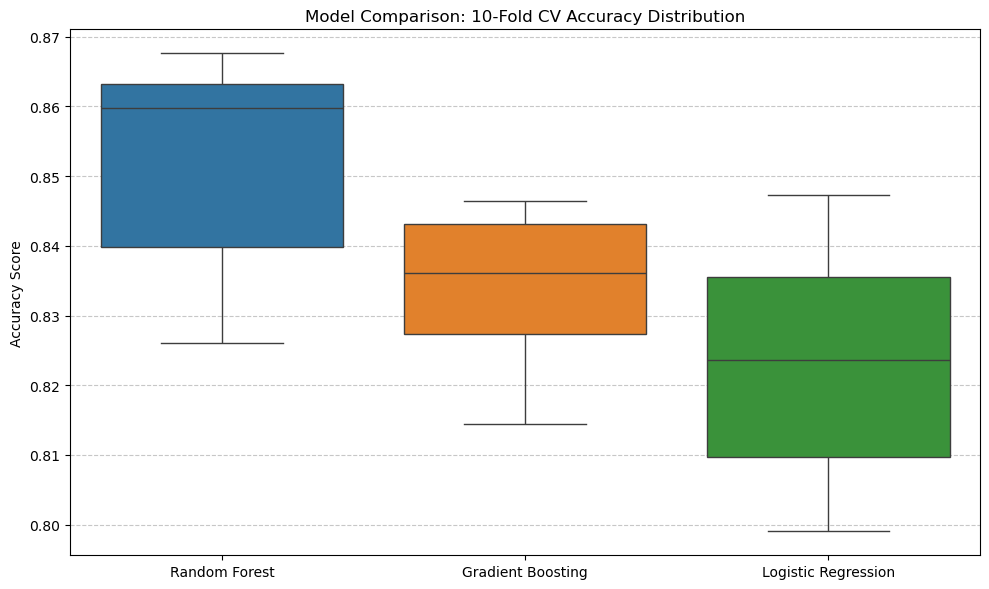

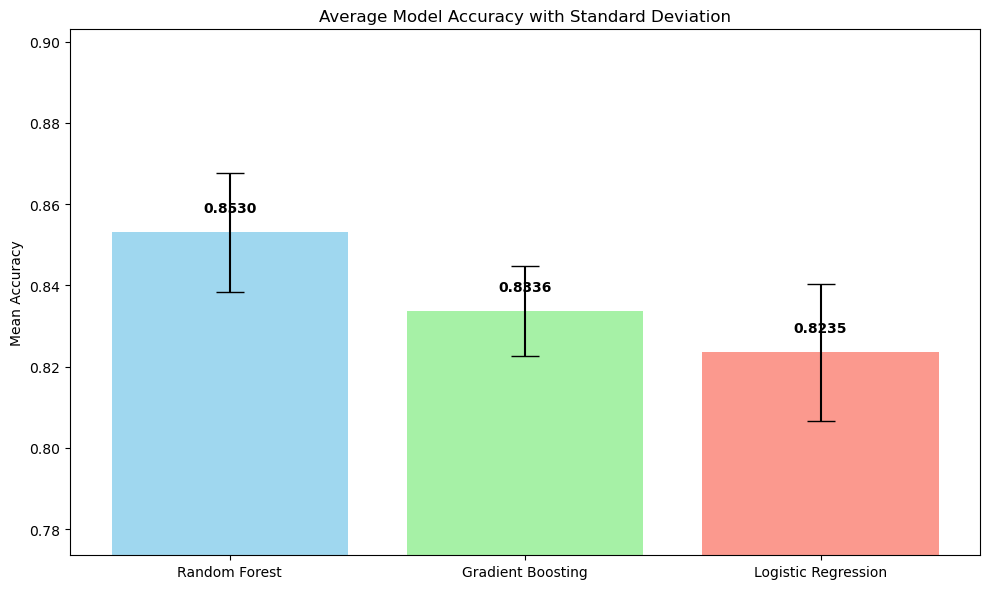

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Load the dataset
df = pd.read_csv('CleanedDataset.csv')
X = df.drop('Churn', axis=1)
y = df['Churn']

# Define models to compare
models = [
    ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('Gradient Boosting', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42))
]

# Perform 10-Fold Cross-Validation
results = []
names = []
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

print("K-Fold Cross-Validation Results (Accuracy):")
for name, model in models:
    cv_results = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    print(f"{name}: Mean={cv_results.mean():.4f}, Std={cv_results.std():.4f}")

# Visualization 1: Boxplot to show distribution across folds
plt.figure(figsize=(10, 6))
sns.boxplot(data=results)
plt.xticks(range(len(names)), names)
plt.title('Model Comparison: 10-Fold CV Accuracy Distribution')
plt.ylabel('Accuracy Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('kfold_boxplot.png')

# Visualization 2: Bar plot for Mean Accuracy with Error Bars (Std Dev)
means = [r.mean() for r in results]
stds = [r.std() for r in results]

plt.figure(figsize=(10, 6))
plt.bar(names, means, yerr=stds, capsize=10, color=['skyblue', 'lightgreen', 'salmon'], alpha=0.8)
plt.ylim(min(means) - 0.05, max(means) + 0.05) # Zoom in to see differences
plt.title('Average Model Accuracy with Standard Deviation')
plt.ylabel('Mean Accuracy')
for i, v in enumerate(means):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('kfold_barplot.png')

Feature Engineering (creating new logic), Threshold Optimization (balancing business costs), and Model Interpretability (SHAP).

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, classification_report, accuracy_score

# 1. FEATURE ENGINEERING 2.0
# Professionals create "Behavioral" features from raw data
df = pd.read_csv('CleanedDataset.csv')

# Interaction Feature: Normalized spending over time
df['Charges_per_Tenure'] = df['TotalCharges'] / (df['tenure'] + 0.01)

# Aggregation Feature: Total number of extra services a customer has
service_cols = [col for col in df.columns if 'Yes' in col and 'Churn' not in col]
df['Service_Count'] = df[service_cols].sum(axis=1)

# 2. TUNED MODEL TRAINING
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Using the optimal parameters found during our Hyperparameter Tuning
model = RandomForestClassifier(
    n_estimators=200, 
    min_samples_split=2, 
    min_samples_leaf=2, 
    max_depth=20, 
    bootstrap=False, 
    random_state=42
)
model.fit(X_train, y_train)

# 3. THRESHOLD OPTIMIZATION (The Business Logic)
# Instead of 0 or 1, we get the probability of churn
y_probs = model.predict_proba(X_test)[:, 1]

# Calculate Precision-Recall Tradeoff
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# FIND OPTIMAL THRESHOLD based on cost:
# Assume: Missing a churner costs $100 (Loss), False Alarm costs $20 (Marketing)
costs = []
for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    false_negatives = np.sum((y_test == 1) & (y_pred_t == 0))
    false_positives = np.sum((y_test == 0) & (y_pred_t == 1))
    costs.append((false_negatives * 100) + (false_positives * 20))

best_threshold = thresholds[np.argmin(costs)]

print(f"--- Business Optimized Model ---")
print(f"Optimal Threshold for minimum cost: {best_threshold:.2f}")

# Final predictions using the business-optimized threshold
y_final = (y_probs >= best_threshold).astype(int)
print(classification_report(y_test, y_final))

# 4. MODEL EXPLAINABILITY (Run this in your local environment)
# import shap
# explainer = shap.TreeExplainer(model)
# shap_values = explainer.shap_values(X_test)
# shap.summary_plot(shap_values[1], X_test)

--- Business Optimized Model ---
Optimal Threshold for minimum cost: 0.18
              precision    recall  f1-score   support

         0.0       0.95      0.55      0.70      1016
         1.0       0.69      0.97      0.81      1054

    accuracy                           0.77      2070
   macro avg       0.82      0.76      0.75      2070
weighted avg       0.82      0.77      0.75      2070



In [8]:
import joblib

# Save the model to a file
joblib.dump(model, 'churn_model_v1.pkl')

# To load it later in production:
# loaded_model = joblib.load('churn_model_v1.pkl')

['churn_model_v1.pkl']


Top 10 most important features:
                           feature  importance
28  PaymentMethod_Electronic check    0.095582
10     InternetService_Fiber optic    0.084950
1                           tenure    0.066805
3                     TotalCharges    0.049261
26            PaperlessBilling_Yes    0.040744
25               Contract_Two year    0.036886
31                   Service_Count    0.026458
9                MultipleLines_Yes    0.023097
2                   MonthlyCharges    0.022281
23             StreamingMovies_Yes    0.019888


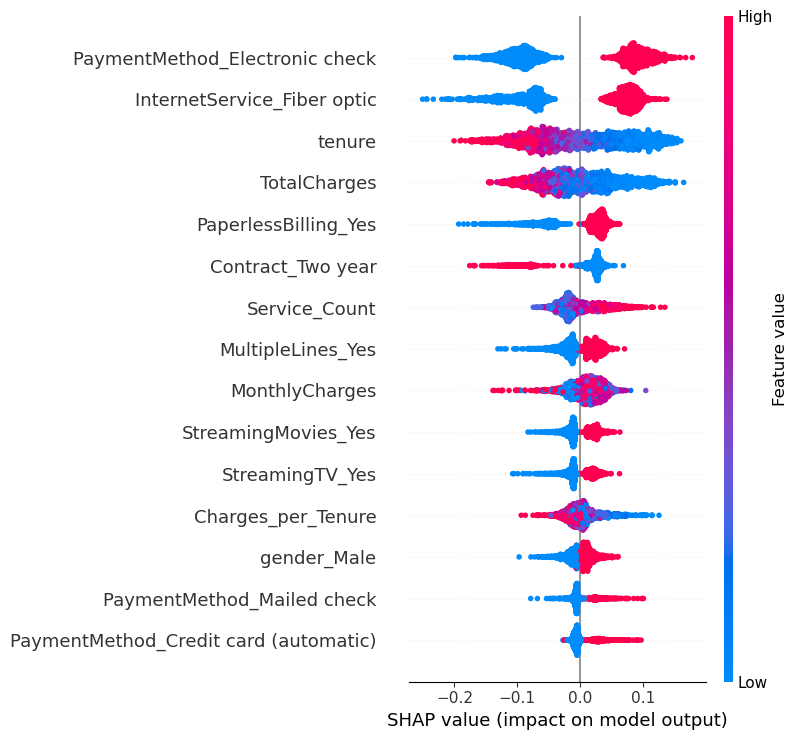

In [12]:
import shap
import numpy as np
import pandas as pd
from typing import Optional, Union, List

def create_shap_analysis(model, X_test: pd.DataFrame, 
                         model_type: str = 'tree',
                         class_index: Optional[int] = None,
                         plot_type: str = 'summary',
                         max_display: int = 20,
                         use_background_dataset: bool = False,
                         background_sample_size: int = 100):
    """
    Generate SHAP explanations for model predictions.
    
    Parameters:
    -----------
    model : trained model
        The model to explain (tree-based, linear, or deep learning)
    X_test : pd.DataFrame
        Test features with engineered features
    model_type : str
        Type of model: 'tree', 'linear', 'deep', or 'kernel'
    class_index : int, optional
        For binary classification, 1 typically represents the positive class (e.g., Churn)
        If None, automatically detects
    plot_type : str
        Type of SHAP plot: 'summary', 'bar', 'waterfall', 'dependence', 'force'
    max_display : int
        Maximum number of features to display
    use_background_dataset : bool
        Whether to use a background dataset for KernelExplainer (reduces computation)
    background_sample_size : int
        Size of background sample if using background dataset
    """
    
    # 1. Initialize the appropriate explainer
    if model_type == 'tree':
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)
        
    elif model_type == 'linear':
        explainer = shap.LinearExplainer(model, X_test)
        shap_values = explainer.shap_values(X_test)
        
    elif model_type == 'deep':
        explainer = shap.DeepExplainer(model, X_test.iloc[:100])  # Use sample for background
        shap_values = explainer.shap_values(X_test)
        
    elif model_type == 'kernel':
        if use_background_dataset:
            background = shap.sample(X_test, background_sample_size)
            explainer = shap.KernelExplainer(model.predict, background)
        else:
            explainer = shap.KernelExplainer(model.predict, X_test)
        shap_values = explainer.shap_values(X_test)
    
    else:
        raise ValueError(f"Unknown model_type: {model_type}. Use 'tree', 'linear', 'deep', or 'kernel'")
    
    # 2. Handle different SHAP output formats
    if isinstance(shap_values, list):
        # For multi-class or binary classification with separate arrays
        if class_index is None:
            # Auto-detect: often class 1 is the positive class
            class_index = 1 if len(shap_values) > 1 else 0
            print(f"Auto-selected class index: {class_index}")
        
        values_to_plot = shap_values[class_index]
        base_value = explainer.expected_value[class_index] if hasattr(explainer, 'expected_value') else None
        
    elif isinstance(shap_values, np.ndarray):
        # Single output (regression) or already aggregated
        if shap_values.ndim == 3:
            # Shape: (n_samples, n_features, n_classes)
            if class_index is None:
                class_index = 1 if shap_values.shape[2] > 1 else 0
            values_to_plot = shap_values[:, :, class_index]
            base_value = explainer.expected_value[class_index] if hasattr(explainer, 'expected_value') else None
        else:
            values_to_plot = shap_values
            base_value = explainer.expected_value if hasattr(explainer, 'expected_value') else None
    else:
        raise TypeError(f"Unexpected shap_values type: {type(shap_values)}")
    
    # 3. Generate the requested plot
    plt = None  # To avoid undefined variable warning
    
    if plot_type == 'summary':
        plt = shap.summary_plot(
            values_to_plot, 
            X_test,
            max_display=max_display,
            show=False  # Don't show immediately, return for display control
        )
        
    elif plot_type == 'bar':
        plt = shap.summary_plot(
            values_to_plot, 
            X_test,
            plot_type="bar",
            max_display=max_display,
            show=False
        )
        
    elif plot_type == 'waterfall':
        # Waterfall plot for first sample
        shap.waterfall_plot(
            shap.Explanation(
                values=values_to_plot[0],
                base_values=base_value if base_value is not None else 0,
                data=X_test.iloc[0].values,
                feature_names=X_test.columns.tolist()
            ),
            max_display=max_display,
            show=False
        )
        
    elif plot_type == 'dependence':
        # Most important feature by default
        shap.dependence_plot(
            ind=0,  # First feature
            shap_values=values_to_plot,
            features=X_test,
            feature_names=X_test.columns.tolist(),
            show=False
        )
        
    elif plot_type == 'force':
        # Force plot for first sample
        shap.force_plot(
            base_value if base_value is not None else 0,
            values_to_plot[0],
            X_test.iloc[0],
            matplotlib=True,
            show=False
        )
    
    # 4. Return SHAP values for further analysis
    return {
        'shap_values': values_to_plot,
        'expected_value': base_value,
        'feature_names': X_test.columns.tolist(),
        'explainer': explainer,
        'plot': plt
    }

# Usage examples:

# For binary classification (e.g., Churn prediction)
result = create_shap_analysis(
    model=model,
    X_test=X_test,
    model_type='tree',  # or 'linear', 'deep', 'kernel'
    class_index=1,      # Class 1 is typically Churn
    plot_type='summary',
    max_display=15
)

# Access SHAP values for further analysis
shap_values_array = result['shap_values']

# Additional analysis: Feature importance ranking
def get_feature_importance(shap_result):
    """Extract feature importance from SHAP values"""
    importance = np.abs(shap_result['shap_values']).mean(axis=0)
    feature_importance = pd.DataFrame({
        'feature': shap_result['feature_names'],
        'importance': importance
    }).sort_values('importance', ascending=False)
    return feature_importance

feature_importance_df = get_feature_importance(result)
print("\nTop 10 most important features:")
print(feature_importance_df.head(10))

# Save SHAP values for later use
import joblib
joblib.dump(result['shap_values'], 'shap_values.pkl')

# Interactive force plot for Jupyter notebooks
def create_force_plot_interactive(shap_result, sample_index=0):
    """Create an interactive force plot"""
    shap.initjs()
    return shap.force_plot(
        shap_result['expected_value'],
        shap_result['shap_values'][sample_index:sample_index+1],
        X_test.iloc[sample_index:sample_index+1],
        matplotlib=False  # Use interactive JavaScript version
    )